In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries are  imported")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries are  imported
Pandas version: 2.3.3
NumPy version: 2.3.5


In [3]:
# Cell 2: Load datasets
train = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
items = pd.read_csv('../data/raw/items.csv')
stores = pd.read_csv('../data/raw/stores.csv')
holidays = pd.read_csv('../data/raw/holidays_events.csv', parse_dates=['date'])


print(f" Train: {train.shape}, Items: {items.shape}, Stores: {stores.shape}, Holidays: {holidays.shape}")


C:\Users\User\AppData\Local\Temp\ipykernel_29864\4138928436.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])


 Train: (125497040, 6), Items: (4100, 4), Stores: (54, 5), Holidays: (350, 6)


In [4]:
# Train data
print(train.head())
print(train.info())
print(train.describe())
print(train.columns.tolist())


   id       date  store_nbr  item_nbr  unit_sales onpromotion
0   0 2013-01-01         25    103665         7.0         NaN
1   1 2013-01-01         25    105574         1.0         NaN
2   2 2013-01-01         25    105575         2.0         NaN
3   3 2013-01-01         25    108079         1.0         NaN
4   4 2013-01-01         25    108701         1.0         NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125497040 entries, 0 to 125497039
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   item_nbr     int64         
 4   unit_sales   float64       
 5   onpromotion  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 5.6+ GB
None
                 id                           date     store_nbr  \
count  1.254970e+08                      125497040  1.254970e+08   
mean   6.274852e+07  2015-

In [5]:
# Items data
print(items.head(10))
print(items['family'].value_counts())
perishable = items[items['perishable']==1]
print(f"Perishable products: {len(perishable)}")



   item_nbr        family  class  perishable
0     96995     GROCERY I   1093           0
1     99197     GROCERY I   1067           0
2    103501      CLEANING   3008           0
3    103520     GROCERY I   1028           0
4    103665  BREAD/BAKERY   2712           1
5    105574     GROCERY I   1045           0
6    105575     GROCERY I   1045           0
7    105576     GROCERY I   1045           0
8    105577     GROCERY I   1045           0
9    105693     GROCERY I   1034           0
family
GROCERY I                     1334
BEVERAGES                      613
CLEANING                       446
PRODUCE                        306
DAIRY                          242
PERSONAL CARE                  153
BREAD/BAKERY                   134
HOME CARE                      108
DELI                            91
MEATS                           84
HOME AND KITCHEN I              77
LIQUOR,WINE,BEER                73
FROZEN FOODS                    55
POULTRY                         54
HOME AND

In [6]:
# Stores data
print(stores.head())
print(stores['city'].value_counts())
print(stores['type'].value_counts())


   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Latacunga         2
Machala           2
Manta             2
Ambato            2
Cayambe           1
Riobamba          1
Ibarra            1
Salinas           1
Puyo              1
Guaranda          1
Quevedo           1
Babahoyo          1
Daule             1
Playas            1
Loja              1
Libertad          1
Esmeraldas        1
El Carmen         1
Name: count, dtype: int64
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


In [7]:
# Holidays
print(holidays.head(10))
print(holidays['type'].value_counts())
print(holidays['locale'].value_counts())


        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   
5 2012-05-12  Holiday     Local        Puyo         Cantonizacion del Puyo   
6 2012-06-23  Holiday     Local    Guaranda      Cantonizacion de Guaranda   
7 2012-06-25  Holiday  Regional    Imbabura  Provincializacion de Imbabura   
8 2012-06-25  Holiday     Local   Latacunga     Cantonizacion de Latacunga   
9 2012-06-25  Holiday     Local     Machala           Fundacion de Machala   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
5        False  
6        False  
7    

In [8]:
# Date range
print(train['date'].min(), train['date'].max())

# Missing values
print(train.isnull().sum())

# Sales distribution
print(train['unit_sales'].describe())
print(f"Negative sales: {(train['unit_sales'] < 0).sum()}")
print(f"Zero sales: {(train['unit_sales'] == 0).sum()} / {len(train)}")



2013-01-01 00:00:00 2017-08-15 00:00:00
id                    0
date                  0
store_nbr             0
item_nbr              0
unit_sales            0
onpromotion    21657651
dtype: int64
count    1.254970e+08
mean     8.554865e+00
std      2.360515e+01
min     -1.537200e+04
25%      2.000000e+00
50%      4.000000e+00
75%      9.000000e+00
max      8.944000e+04
Name: unit_sales, dtype: float64
Negative sales: 7795
Zero sales: 0 / 125497040


In [9]:
# Sales distribution
print(train['unit_sales'].describe())

print(f"Negative sales: {(train['unit_sales'] < 0).sum()}")
print(f"Zero sales: {(train['unit_sales'] == 0).sum()}")

print(
    f"Zero sales percentage: "
    f"{(train['unit_sales'] == 0).sum() / len(train) * 100:.2f}%"
)


count    1.254970e+08
mean     8.554865e+00
std      2.360515e+01
min     -1.537200e+04
25%      2.000000e+00
50%      4.000000e+00
75%      9.000000e+00
max      8.944000e+04
Name: unit_sales, dtype: float64
Negative sales: 7795
Zero sales: 0
Zero sales percentage: 0.00%


In [10]:
# Analyze stores by total sales
print("="*60)
print("ANALYZING STORES BY SALES PERFORMANCE")
print("="*60)

# calculate total sales per store
store_sales = train.groupby('store_nbr')['unit_sales'].agg([
    ('total_sales', 'sum'),
    ('avg_sales', 'mean'),
    ('num_transactions', 'count')
]).sort_values('total_sales', ascending=False)

print("\nTop 20 Stores by Total Sales:")
print(store_sales.head(20))

# Merge with store metadata to see location
store_analysis = store_sales.merge(stores, on='store_nbr', how='left')
print("\nTop 20 Stores with Location Info:")
print(store_analysis.head(20)[['store_nbr','total_sales', 'avg_sales', 'city', 'state', 'type', 'cluster']])

ANALYZING STORES BY SALES PERFORMANCE

Top 20 Stores by Total Sales:
            total_sales  avg_sales  num_transactions
store_nbr                                           
44         6.208754e+07  17.673206           3513089
45         5.449801e+07  15.641273           3484244
47         5.094831e+07  14.735988           3457407
3          5.048190e+07  14.842100           3401264
49         4.342009e+07  12.990183           3342531
46         4.189605e+07  12.491779           3353890
48         3.593313e+07  11.102387           3236523
51         3.291148e+07  11.118628           2960031
8          3.049134e+07   9.349775           3261184
50         2.865302e+07   8.974918           3192566
11         2.832556e+07  11.028990           2568282
7          2.695202e+07   9.226340           2921204
9          2.640940e+07   9.521052           2773790
6          2.518368e+07   8.150587           3089799
24         2.376773e+07   8.580752           2769889
2          2.155462e+07   7.21

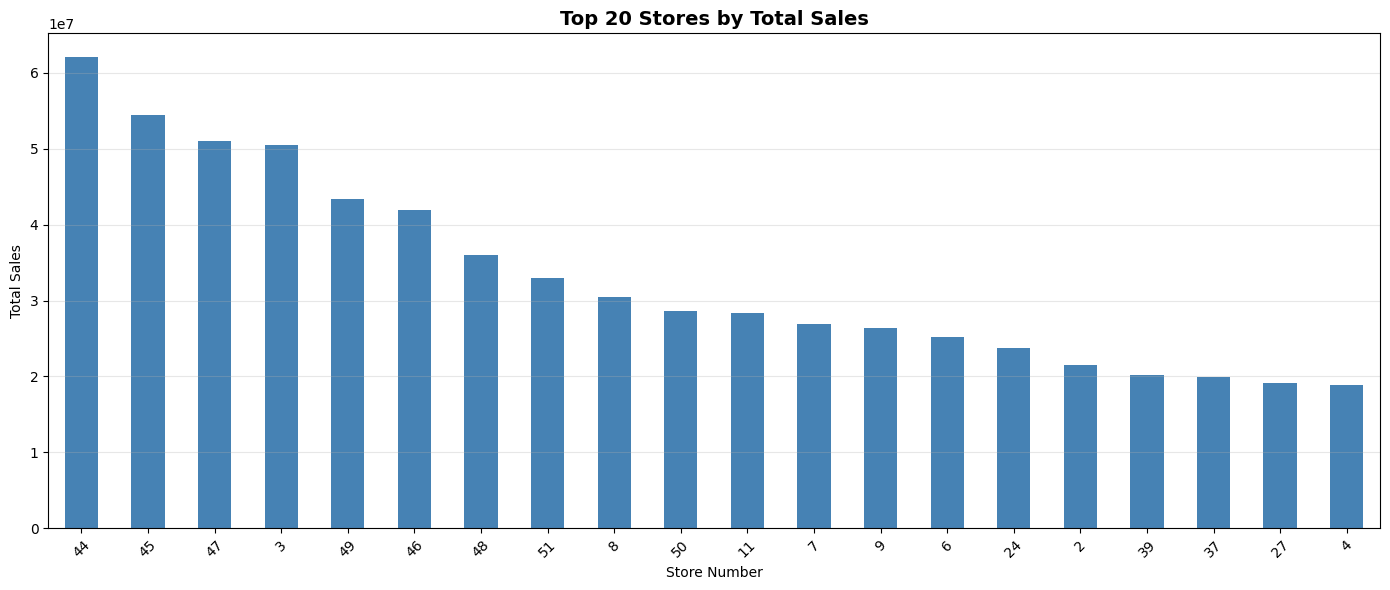


Stores by City:
city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Latacunga         2
Machala           2
Manta             2
Ambato            2
Cayambe           1
Riobamba          1
Name: count, dtype: int64


In [11]:
# Plot top stores
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
store_sales.head(20)['total_sales'].plot(kind='bar', color='steelblue')
plt.title('Top 20 Stores by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nStores by City:")
print(stores['city'].value_counts().head(10))

In [ ]:

store_dates = train.groupby('store_nbr')['date'].agg([
    ('first_date', 'min'),
    ('last_date', 'max'),
    ('num_days', 'count')
]).sort_values('num_days', ascending=False)



store_dates['date_range_days'] = (store_dates['last_date'] - store_dates['first_date']).dt.days

print("\nStore Data Availability (Top 20):")
print(store_dates.head(20))


store_final = store_sales.merge(store_dates, on='store_nbr').merge(stores, on='store_nbr')
store_final = store_final.sort_values('total_sales', ascending=False)

print("\n" ) 

print("RECOMMENDED STORES (Top 10):")

print(store_final.head(10)[['store_nbr','total_sales', 'avg_sales', 'num_days', 'city', 'type']])


Store Data Availability (Top 20):
          first_date  last_date  num_days  date_range_days
store_nbr                                                 
44        2013-01-02 2017-08-15   3513089             1686
45        2013-01-02 2017-08-15   3484244             1686
47        2013-01-02 2017-08-15   3457407             1686
3         2013-01-02 2017-08-15   3401264             1686
46        2013-01-02 2017-08-15   3353890             1686
49        2013-01-02 2017-08-15   3342531             1686
8         2013-01-02 2017-08-15   3261184             1686
48        2013-01-02 2017-08-15   3236523             1686
50        2013-01-02 2017-08-15   3192566             1686
6         2013-01-02 2017-08-15   3089799             1686
2         2013-01-02 2017-08-15   2987840             1686
51        2013-01-02 2017-08-15   2960031             1686
7         2013-01-02 2017-08-15   2921204             1686
37        2013-01-02 2017-08-15   2831691             1686
4         2013-01-02 

In [13]:
print("="*60)
print("ANALYZING PERISHABLE PRODUCTS")
print("="*60)

# Merge train with items
train_items = train.merge(
    items[['item_nbr', 'family', 'class', 'perishable']], 
    on='item_nbr', 
    how='left'
)

# Filter only perishable
perishable_sales = train_items[train_items['perishable'] == 1]

print(f"\nTotal perishable transactions: {len(perishable_sales):,}")
print(f"Unique perishable products: {perishable_sales['item_nbr'].nunique()}")

# Analyze by product
product_analysis = perishable_sales.groupby('item_nbr')['unit_sales'].agg([
    ('total_sales', 'sum'),
    ('avg_sales', 'mean'),
    ('num_transactions', 'count')
]).sort_values('total_sales', ascending=False)

# Merge with item metadata
product_analysis = product_analysis.merge(
    items[['item_nbr', 'family', 'class', 'perishable']], 
    on='item_nbr', 
    how='left'
)

print("\nTop 20 Perishable Products by Total Sales:")
print(product_analysis.head(20))

ANALYZING PERISHABLE PRODUCTS

Total perishable transactions: 31,702,536
Unique perishable products: 986

Top 20 Perishable Products by Total Sales:
    item_nbr   total_sales   avg_sales  num_transactions        family  class  \
0    1503844  6.264200e+06  227.929984             27483       PRODUCE   2022   
1    1473474  4.990323e+06  103.884977             48037       PRODUCE   2014   
2     502331  3.703350e+06   44.364780             83475  BREAD/BAKERY   2702   
3     584028  3.252203e+06   77.968044             41712         MEATS   2302   
4    1167614  3.222418e+06   97.008188             33218          EGGS   2502   
5     584126  2.689296e+06   67.957856             39573         MEATS   2302   
6     903285  2.648742e+06   40.777481             64956       POULTRY   2416   
7    1695835  2.527146e+06   73.446466             34408       PRODUCE   2004   
8     903284  2.239207e+06   31.980453             70018       POULTRY   2416   
9     457928  2.225450e+06   30.540844   

In [14]:
# Sales frequency per item
item_activity = (
    perishable_sales
    .groupby('item_nbr')['unit_sales']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
)

print("\nTop 20 most consistently selling perishable items:")
print("(Value = % of days with sales > 0)")
print(item_activity.head(20))

# merge activity into product_analysis
product_analysis = product_analysis.reset_index().merge(
    item_activity.rename('activity_rate'),
    on='item_nbr',
    how='left'
).set_index('item_nbr')

print("\nProducts with High Sales + High Activity:")
print(product_analysis[['family', 'total_sales', 'activity_rate']].head(20))


Top 20 most consistently selling perishable items:
(Value = % of days with sales > 0)
item_nbr
2112404    1.0
2111870    1.0
2087567    1.0
2087543    1.0
2087374    1.0
2036618    1.0
2036574    1.0
2036465    1.0
2036460    1.0
2034104    1.0
2033805    1.0
2033699    1.0
2033554    1.0
2032088    1.0
2031378    1.0
2031309    1.0
2031273    1.0
260628     1.0
227111     1.0
2028754    1.0
Name: unit_sales, dtype: float64

Products with High Sales + High Activity:
                family   total_sales  activity_rate
item_nbr                                           
1503844        PRODUCE  6.264200e+06       1.000000
1473474        PRODUCE  4.990323e+06       0.999979
502331    BREAD/BAKERY  3.703350e+06       1.000000
584028           MEATS  3.252203e+06       0.999976
1167614           EGGS  3.222418e+06       0.999970
584126           MEATS  2.689296e+06       1.000000
903285         POULTRY  2.648742e+06       0.999938
1695835        PRODUCE  2.527146e+06       1.000000
903284  


Perishable Product Families by Sales:
family
PRODUCE           1.227047e+08
DAIRY             6.448726e+07
BREAD/BAKERY      4.213395e+07
POULTRY           3.187600e+07
MEATS             3.108647e+07
DELI              2.411032e+07
EGGS              1.558830e+07
PREPARED FOODS    8.799871e+06
SEAFOOD           2.015396e+06
Name: unit_sales, dtype: float64


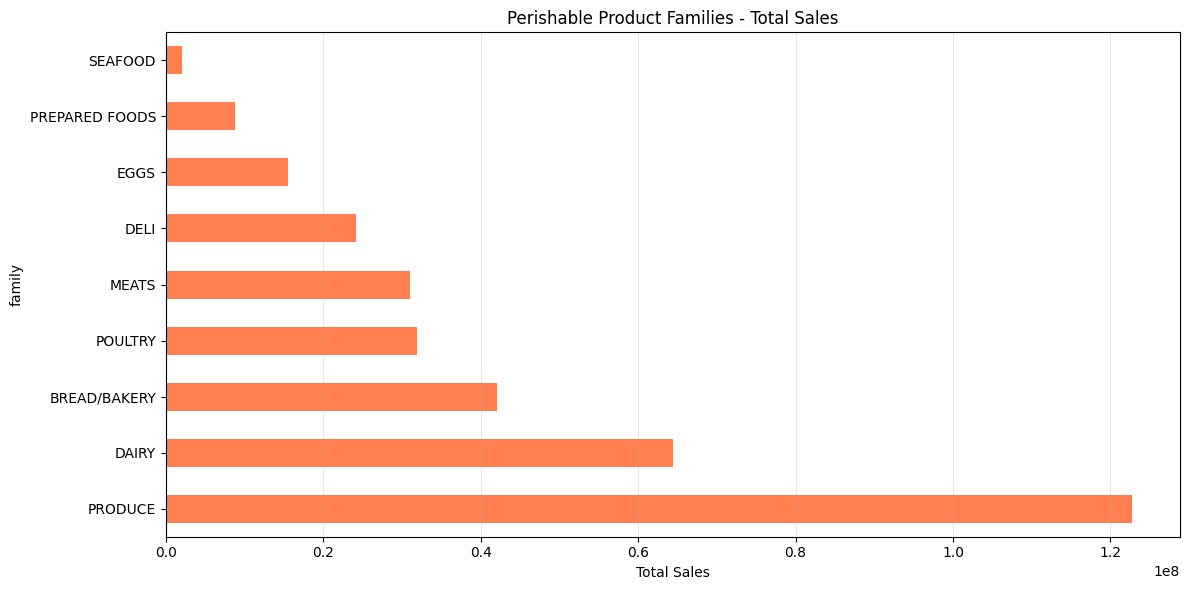

In [15]:
# Analyze by family
family_sales = perishable_sales.groupby('family')['unit_sales'].sum().sort_values(ascending=False)

print("\nPerishable Product Families by Sales:")
print(family_sales)

# Plot
plt.figure(figsize=(12, 6))
family_sales.plot(kind='barh', color='coral')
plt.title('Perishable Product Families - Total Sales')
plt.xlabel('Total Sales')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print("="*60)
print("all the products (all perishable and non)")
print("="*60)

# not filter by perishable so  analyze everything
all_products = train_items.groupby('item_nbr')['unit_sales'].agg([
    ('total_sales', 'sum'),
    ('avg_sales', 'mean'),
    ('num_transactions', 'count')
]).sort_values('total_sales', ascending=False)

# Merge with item metadata
all_products = all_products.merge(
    items[['item_nbr', 'family', 'class', 'perishable']], 
    on='item_nbr', 
    how='left'
)

# Add activity rate
all_activity = (
    train_items
    .groupby('item_nbr')['unit_sales']
    .apply(lambda x: (x > 0).mean())
)

all_products = all_products.reset_index().merge(
    all_activity.rename('activity_rate'),
    on='item_nbr',
    how='left'
).set_index('item_nbr')

print("\n top 20 products (from all categories):")
print(all_products.head(20))

print("\n BREAKDOWN BY PERISHABILITY:")
print(all_products.head(20)['perishable'].value_counts())

all the products (all perishable and non)

 top 20 products (from all categories):
          index   total_sales   avg_sales  num_transactions        family  \
item_nbr                                                                    
1503844       0  6.264200e+06  227.929984             27483       PRODUCE   
1047679       1  5.512875e+06   68.302194             80713     BEVERAGES   
1473474       2  4.990323e+06  103.884977             48037       PRODUCE   
364606        3  4.416426e+06   53.013228             83308     GROCERY I   
819932        4  4.410943e+06   58.699870             75144     BEVERAGES   
1463992       5  4.408545e+06   88.715614             49693     BEVERAGES   
807493        6  4.321424e+06   54.095562             79885     BEVERAGES   
265559        7  4.112827e+06   49.524089             83047     GROCERY I   
502331        8  3.703350e+06   44.364780             83475  BREAD/BAKERY   
314384        9  3.544341e+06   42.472630             83450     GROCER

In [17]:
# Check which stores sold item 1167614

item_id = 1167614

stores_selling_item = train[train['item_nbr'] == item_id]['store_nbr'].unique()

print(f"Item {item_id} was sold in {len(stores_selling_item)} stores.")
print("Store numbers:")
print(sorted(stores_selling_item))


Item 1167614 was sold in 28 stores.
Store numbers:
[np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(26), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(39), np.int64(40), np.int64(43), np.int64(54)]


In [18]:
item_id = 1167614

store_sales = (
    train[train['item_nbr'] == item_id]
    .groupby('store_nbr')['unit_sales']
    .sum()
    .sort_values(ascending=False)
)

print(store_sales)


store_nbr
39    474054.0
31    256326.0
35    227909.0
32    190980.0
28    168681.0
16    168394.0
11    163983.0
17    156855.0
33    140691.0
9     135470.0
30    122166.0
43    113461.0
34    100592.0
21     84260.0
36     83413.0
40     76017.0
12     71783.0
29     68689.0
15     67343.0
18     62414.0
54     61287.0
20     57794.0
13     54899.0
19     45599.0
10     40079.0
14     16499.0
22     12691.0
26        89.0
Name: unit_sales, dtype: float64
